# Explore Synthesized Data
Inspect the dataset generated by `arxiv_synthesize.py`.

In [2]:
import pandas as pd
from pathlib import Path

PARQUET_PATH = "/home/phudishp/cartridges/experiments/continual_learning/data/eval/eval_phase1.parquet"
print(f"Loading: {PARQUET_PATH}")

Loading: /home/phudishp/cartridges/experiments/continual_learning/data/eval/eval_phase1.parquet


In [3]:
df = pd.read_parquet(PARQUET_PATH)
df.head(10)

,messages,system_prompt,metadata,type
0,[{'content': 'Where is AMD's principal executi...,"<document name=""AMD_2021_10K"">\nUNITED STATES ...","{'category': 'stable', 'difficulty': 'easy', '...",continual_eval
1,[{'content': 'Under which state's laws was AMD...,"<document name=""AMD_2021_10K"">\nUNITED STATES ...","{'category': 'stable', 'difficulty': 'easy', '...",continual_eval
2,[{'content': 'On which stock exchange is AMD's...,"<document name=""AMD_2021_10K"">\nUNITED STATES ...","{'category': 'stable', 'difficulty': 'easy', '...",continual_eval
3,[{'content': 'What is the par value per share ...,"<document name=""AMD_2021_10K"">\nUNITED STATES ...","{'category': 'stable', 'difficulty': 'easy', '...",continual_eval
4,[{'content': 'What fiscal year convention does...,"<document name=""AMD_2021_10K"">\nUNITED STATES ...","{'category': 'stable', 'difficulty': 'medium',...",continual_eval
5,[{'content': 'What is AMD's registrant telepho...,"<document name=""AMD_2021_10K"">\nUNITED STATES ...","{'category': 'stable', 'difficulty': 'easy', '...",continual_eval
6,[{'content': 'Is AMD a fabless semiconductor c...,"<document name=""AMD_2021_10K"">\nUNITED STATES ...","{'category': 'stable', 'difficulty': 'medium',...",continual_eval
7,[{'content': 'Which third-party foundries does...,"<document name=""AMD_2021_10K"">\nUNITED STATES ...","{'category': 'stable', 'difficulty': 'medium',...",continual_eval
8,[{'content': 'What gaming console products are...,"<document name=""AMD_2021_10K"">\nUNITED STATES ...","{'category': 'stable', 'difficulty': 'medium',...",continual_eval
9,[{'content': 'Who is AMD's Chief Executive Off...,"<document name=""AMD_2021_10K"">\nUNITED STATES ...","{'category': 'stable', 'difficulty': 'easy', '...",continual_eval


In [12]:
df.iloc[0]['messages'][0]

{'content': "Where is AMD's principal executive office located?",
 'role': 'user',
 'token_ids': None,
 'top_logprobs': None}

In [1]:
import pandas as pd
from pathlib import Path

PARQUET_PATH = sorted(Path("../outputs").rglob("dataset_clean.parquet"))[-2]
print(f"Loading: {PARQUET_PATH}")
df = pd.read_parquet(PARQUET_PATH)
df.head(100)

Loading: ../outputs/2026-02-09-22-48-42-synthesize_pepsi/synthesize_pepsi_meta-llama/Llama-3.2-3B-Instruct_n65536-0/artifact/dataset_clean.parquet


,system_prompt,type,messages,metadata
0,\nYou are in a conversation about the followin...,todo,"[{'content': 'How many times does the word ""im...",{'seed_prompt': ' Please generate a qu...
1,\nYou are in a conversation about the followin...,todo,[{'content': 'What is the average annual amort...,{'seed_prompt': ' Please generate a qu...
2,\nYou are in a conversation about the followin...,todo,[{'content': 'What is the name of the company ...,{'seed_prompt': ' Please generate a qu...
3,\nYou are in a conversation about the followin...,todo,[{'content': 'What is the approximate number o...,{'seed_prompt': ' Please generate a mu...
4,\nYou are in a conversation about the followin...,todo,[{'content': 'What is the effective date of Ar...,{'seed_prompt': ' Please generate a qu...
...,...,...,...,...
95,\nYou are in a conversation about the followin...,todo,"[{'content': 'How many times does the word ""20...",{'seed_prompt': ' Please generate a qu...
96,\nYou are in a conversation about the followin...,todo,[{'content': 'What is the estimated net asset ...,{'seed_prompt': ' Please generate a mu...
97,\nYou are in a conversation about the followin...,todo,[{'content': 'What is the name of the company'...,{'seed_prompt': ' Please generate a qu...
98,\nYou are in a conversation about the followin...,todo,[{'content': 'What is the effective date of th...,{'seed_prompt': ' Please generate a qu...


## Overview

In [2]:
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print()
print(df.dtypes)
print()
print("type value counts:")
print(df["type"].value_counts())

Shape: (65536, 4)
Columns: ['system_prompt', 'type', 'messages', 'metadata']

system_prompt       str
type                str
messages         object
metadata         object
dtype: object

type value counts:
type
todo    65536
Name: count, dtype: int64


## Browse conversations

In [4]:
def show_conversation(row, max_content_len=1000000):
    """Pretty-print a single conversation."""
    print(f"=== Row {row.name}  |  type={row['type']} ===")
    sp = row["system_prompt"]
    # if len(sp) > max_content_len:
    #     sp = sp[:max_content_len] + "..."
    # print(f"\n[SYSTEM PROMPT]\n{sp}")
    for msg in row["messages"]:
        role = msg["role"].upper()
        content = msg["content"]
        if len(content) > max_content_len:
            content = content[:max_content_len] + "..."
        print(f"\n[{role}]\n{content}")
    print("\n")

for _, row in df.head(100).iterrows():
    show_conversation(row)

=== Row 0  |  type=todo ===

[USER]
How many times does the word "impaired" appear in the document?

[ASSISTANT]
The word "impaired" appears 3 times in the document.


=== Row 1  |  type=todo ===

[USER]
What is the average annual amortization expense for the next five years, based on the total projected amortization of $77 million over the same period, assuming a straight-line basis of amortization?

[ASSISTANT]
To calculate the average annual amortization expense, we need to divide the total projected amortization by the number of years.

Total projected amortization = $77 million
Number of years = 5

Average annual amortization expense = Total projected amortization / Number of years
= $77 million / 5
= $15.4 million per year

So, the average annual amortization expense for the next five years is $15.4 million.


=== Row 2  |  type=todo ===

[USER]
What is the name of the company that PepsiCo agreed to distribute Celsius energy drinks in the United States, and in what year was this 

## Stats

In [26]:
df["num_turns"] = df["messages"].apply(len)
df["total_chars"] = df["messages"].apply(
    lambda msgs: sum(len(m["content"]) for m in msgs)
)
df["total_tokens"] = df["messages"].apply(
    lambda msgs: sum(len(m.get("token_ids", [])) for m in msgs)
)

print("Turns per conversation:")
print(df["num_turns"].describe())
print()
print("Total chars per conversation:")
print(df["total_chars"].describe())
print()
print("Total tokens per conversation:")
print(df["total_tokens"].describe())

Turns per conversation:
count    65536.0
mean         2.0
std          0.0
min          2.0
25%          2.0
50%          2.0
75%          2.0
max          2.0
Name: num_turns, dtype: float64

Total chars per conversation:
count    65536.000000
mean      1372.022827
std       1103.474789
min         69.000000
25%        409.000000
50%       1126.000000
75%       2060.000000
max       9106.000000
Name: total_chars, dtype: float64

Total tokens per conversation:
count    65536.000000
mean       308.149536
std        247.760336
min         20.000000
25%         89.000000
50%        256.000000
75%        457.000000
max       1536.000000
Name: total_tokens, dtype: float64


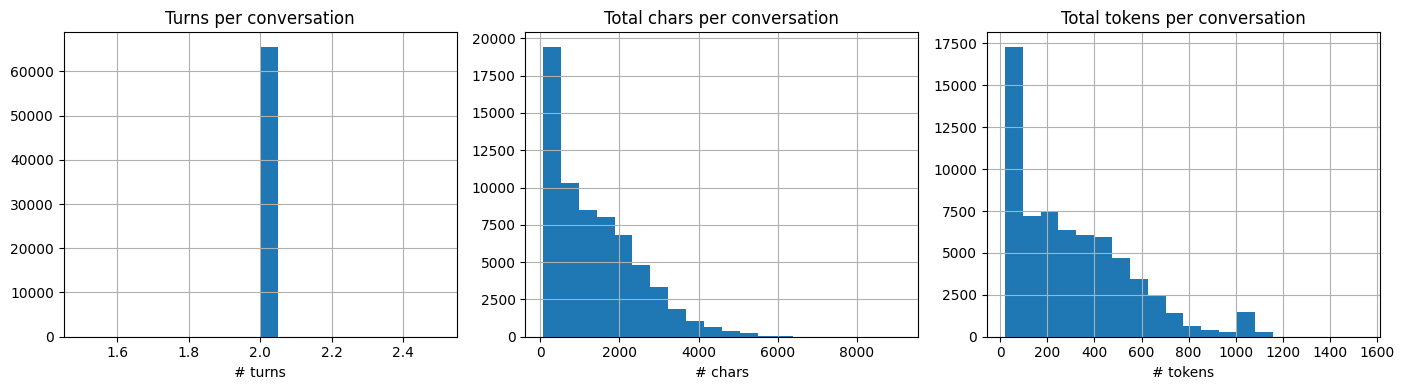

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df["num_turns"].hist(ax=axes[0], bins=20)
axes[0].set_title("Turns per conversation")
axes[0].set_xlabel("# turns")

df["total_chars"].hist(ax=axes[1], bins=20)
axes[1].set_title("Total chars per conversation")
axes[1].set_xlabel("# chars")

df["total_tokens"].hist(ax=axes[2], bins=20)
axes[2].set_title("Total tokens per conversation")
axes[2].set_xlabel("# tokens")

plt.tight_layout()
plt.show()

## System prompts

In [ ]:
for i, sp in enumerate(df["system_prompt"].drop_duplicates().head(3)):
    print(f"--- System prompt #{i+1} (first 600 chars) ---")
    print(sp[:600])
    print()

print(f"Unique system prompts: {df['system_prompt'].nunique()} / {len(df)}")

In [7]:

import pyarrow.parquet as pq
from pathlib import Path

PARQUET_PATH = sorted(Path("../../outputs").rglob("dataset.parquet"))[-1]
pf = pq.ParquetFile(PARQUET_PATH)
print(pf.schema_arrow)
print(f"\nRow groups: {pf.metadata.num_row_groups}")


messages: list<element: struct<content: string, role: string, token_ids: list<element: int64>, top_logprobs: s (... 133 chars omitted)
  child 0, element: struct<content: string, role: string, token_ids: list<element: int64>, top_logprobs: struct<logprobs (... 118 chars omitted)
      child 0, content: string
      child 1, role: string
      child 2, token_ids: list<element: int64>
          child 0, element: int64
      child 3, top_logprobs: struct<logprobs: list<element: float>, shape: list<element: int64>, token_id: list<element: int32>,  (... 32 chars omitted)
          child 0, logprobs: list<element: float>
              child 0, element: float
          child 1, shape: list<element: int64>
              child 0, element: int64
          child 2, token_id: list<element: int32>
              child 0, element: int32
          child 3, token_idx: list<element: int64>
              child 0, element: int64
system_prompt: string
metadata: struct<initial_system_prompt: string, seed_pr

In [8]:

import json

# Read flat columns directly
flat_cols = ["system_prompt", "type"]
df_flat = pq.read_table(str(PARQUET_PATH), columns=flat_cols).to_pandas()

# Read nested columns via to_pylist() which bypasses the chunked array issue
table = pq.read_table(str(PARQUET_PATH), columns=["messages", "metadata"])
messages_list = table.column("messages").to_pylist()
metadata_list = table.column("metadata").to_pylist()

df = df_flat.copy()
df["messages"] = messages_list
df["metadata"] = metadata_list
print(df.shape)
df.head(2)


ArrowNotImplementedError: Nested data conversions not implemented for chunked array outputs

In [9]:

# Try reading flat columns only with ParquetFile (bypasses dataset scanner)
flat_table = pf.read(columns=["system_prompt", "type"])
print("Flat columns read OK:", flat_table.num_rows, "rows")

# Try reading nested columns
try:
    nested_table = pf.read(columns=["messages", "metadata"])
    print("Nested columns read OK")
except Exception as e:
    print(f"Nested columns failed: {e}")
    # Try reading just messages
    try:
        msg_table = pf.read(columns=["messages"])
        print("messages column read OK")
    except Exception as e2:
        print(f"messages column failed: {e2}")
    try:
        meta_table = pf.read(columns=["metadata"])
        print("metadata column read OK")
    except Exception as e3:
        print(f"metadata column failed: {e3}")


Flat columns read OK: 65536 rows
Nested columns failed: Nested data conversions not implemented for chunked array outputs
messages column read OK
metadata column failed: Nested data conversions not implemented for chunked array outputs


In [10]:

# flat columns + messages work individually, metadata is the problem
# Read what works, then handle metadata via to_pylist()
flat_table = pf.read(columns=["system_prompt", "type"])
msg_table = pf.read(columns=["messages"])

# For metadata, read as arrow and convert to python list
meta_table = pf.read(columns=["metadata"])
metadata_list = meta_table.column("metadata").to_pylist()

df = flat_table.to_pandas()
df["messages"] = msg_table.column("messages").to_pylist()
df["metadata"] = metadata_list
print(df.shape)
df.head(2)


ArrowNotImplementedError: Nested data conversions not implemented for chunked array outputs

In [11]:

# metadata column is the culprit. Try reading it via iter_batches
batches = list(pf.iter_batches(columns=["metadata"], batch_size=65536))
print(f"Got {len(batches)} batches")
meta_list = []
for b in batches:
    meta_list.extend(b.column("metadata").to_pylist())
print(f"metadata rows: {len(meta_list)}")
print(meta_list[0])


ArrowNotImplementedError: Nested data conversions not implemented for chunked array outputs

In [12]:

# The metadata struct with list<null> is unreadable via pyarrow.
# Try reading just the sub-fields of metadata individually
try:
    t = pf.read(columns=["metadata.initial_system_prompt"])
    print("metadata.initial_system_prompt OK")
except Exception as e:
    print(f"metadata.initial_system_prompt: {e}")

try:
    t = pf.read(columns=["metadata.seed_prompt"])
    print("metadata.seed_prompt OK")
except Exception as e:
    print(f"metadata.seed_prompt: {e}")

try:
    t = pf.read(columns=["metadata.tool_calls"])
    print("metadata.tool_calls OK")
except Exception as e:
    print(f"metadata.tool_calls: {e}")


metadata.initial_system_prompt: Nested data conversions not implemented for chunked array outputs
metadata.seed_prompt OK
metadata.tool_calls OK


In [13]:

# metadata.initial_system_prompt is the single problematic sub-field
# It's a string but something about it causes chunked output
# Let's check its size
import pyarrow as pa

# Read what we can, skip problematic field
flat_table = pf.read(columns=["system_prompt", "type"])
msg_table = pf.read(columns=["messages"])

seed_table = pf.read(columns=["metadata.seed_prompt"])
tc_table = pf.read(columns=["metadata.tool_calls"])

df = flat_table.to_pandas()
df["messages"] = msg_table.column("messages").to_pylist()
df["metadata"] = [
    {"seed_prompt": sp, "tool_calls": tc, "initial_system_prompt": None}
    for sp, tc in zip(
        seed_table.column("metadata.seed_prompt").to_pylist(),
        tc_table.column("metadata.tool_calls").to_pylist(),
    )
]
print(df.shape)
df.head(2)


KeyError: 'Field "metadata.seed_prompt" does not exist in schema'

In [14]:

# Check actual column names in the sub-field tables
print("seed_table schema:", seed_table.schema)
print("seed_table columns:", seed_table.column_names)
print()
print("tc_table schema:", tc_table.schema)
print("tc_table columns:", tc_table.column_names)


seed_table schema: metadata: struct<seed_prompt: string>
  child 0, seed_prompt: string
seed_table columns: ['metadata']

tc_table schema: metadata: struct<tool_calls: list<element: null>>
  child 0, tool_calls: list<element: null>
      child 0, element: null
tc_table columns: ['metadata']


In [15]:

# Build df from readable columns, skip metadata.initial_system_prompt
flat_table = pf.read(columns=["system_prompt", "type"])
msg_table = pf.read(columns=["messages"])
seed_table = pf.read(columns=["metadata.seed_prompt"])
tc_table = pf.read(columns=["metadata.tool_calls"])

df = flat_table.to_pandas()
df["messages"] = msg_table.column("messages").to_pylist()

# Extract sub-fields from the struct columns
seed_list = seed_table.column("metadata").to_pylist()
tc_list = tc_table.column("metadata").to_pylist()

df["metadata"] = [
    {"seed_prompt": s["seed_prompt"], "tool_calls": t["tool_calls"], "initial_system_prompt": None}
    for s, t in zip(seed_list, tc_list)
]

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Skipped: metadata.initial_system_prompt (unreadable due to Arrow chunking bug)")
df.head(2)


Shape: (65536, 4)
Columns: ['system_prompt', 'type', 'messages', 'metadata']
Skipped: metadata.initial_system_prompt (unreadable due to Arrow chunking bug)


,system_prompt,type,messages,metadata
0,\nYou are in a conversation about the followin...,todo,"[{'content': 'How many times does the word ""No...",{'seed_prompt': ' Please generate a qu...
1,\nYou are in a conversation about the followin...,todo,[{'content': 'What was the total stockholders'...,{'seed_prompt': ' Please generate a qu...


In [18]:
import pyarrow; print(pyarrow.__version__)

23.0.0


In [22]:

# Check how large the initial_system_prompt strings are
# Read just that sub-field's metadata from the parquet file
import pyarrow.parquet as pq
from pathlib import Path

PARQUET_PATH = sorted(Path("../../outputs").rglob("dataset.parquet"))[-1]
pf = pq.ParquetFile(PARQUET_PATH)

# Check row group size and column sizes
rg = pf.metadata.row_group(0)
print(f"Rows: {rg.num_rows}")
for i in range(rg.num_columns):
    col = rg.column(i)
    print(f"  {col.path_in_schema}: {col.total_uncompressed_size / 1024 / 1024:.1f} MB uncompressed")


Rows: 65536
  messages.list.element.content: 76.9 MB uncompressed
  messages.list.element.role: 0.0 MB uncompressed
  messages.list.element.token_ids.list.element: 31.9 MB uncompressed
  messages.list.element.top_logprobs.logprobs.list.element: 146.8 MB uncompressed
  messages.list.element.top_logprobs.shape.list.element: 0.3 MB uncompressed
  messages.list.element.top_logprobs.token_id.list.element: 72.8 MB uncompressed
  messages.list.element.top_logprobs.token_idx.list.element: 39.6 MB uncompressed
  system_prompt: 2448.6 MB uncompressed
  metadata.initial_system_prompt: 2448.6 MB uncompressed
  metadata.seed_prompt: 0.0 MB uncompressed
  metadata.tool_calls.list.element: 0.0 MB uncompressed
  type: 0.0 MB uncompressed


In [2]:

import pyarrow as pa
import pyarrow.parquet as pq

output_path = str(PARQUET_PATH).replace("dataset.parquet", "dataset_clean.parquet")
table = pa.Table.from_pylist(df.to_dict(orient="records"))
pq.write_table(table, output_path, compression="snappy")

# Verify it's readable with plain pd.read_parquet
import pandas as pd
df_check = pd.read_parquet(output_path)
print(f"Saved to: {output_path}")
print(f"Shape: {df_check.shape}")
print(f"Columns: {df_check.columns.tolist()}")


Saved to: ../../outputs/2026-02-09-22-48-42-synthesize_pepsi/synthesize_pepsi_meta-llama/Llama-3.2-3B-Instruct_n65536-0/artifact/dataset_clean.parquet
Shape: (65536, 4)
Columns: ['system_prompt', 'type', 'messages', 'metadata']
